# Практика 1


In [26]:
import numpy as np 
from sklearn.datasets import make_regression 
from sklearn.preprocessing import StandardScaler

X, y = make_regression(n_samples = 1000, n_features = 10, noise = 10.0, random_state = 42)

X = StandardScaler().fit_transform(X)

n = X.shape[0]


H = (2 /n) * X.T @ X

eigvals = np.linalg.eigvals(H)
mui = np.min(eigvals)
L = np.max(eigvals)

k = L / mui
N = 2 / (mui + L)

print(f' Матрица Гессиана : {H} ')
print(f'Максимальное значение : {mui}')
print(f'Минимальное значение : {L}')
print(f' Число обусловнности : {k}')
print(f'Оптимальный постоянный шаг : {N}')


 Матрица Гессиана : [[ 2.00000000e+00 -2.94581537e-02 -4.59404499e-02 -9.55203586e-02
   1.06004235e-02  6.22938063e-03 -8.03889362e-02 -5.41126982e-02
  -1.24743239e-01 -1.78000164e-02]
 [-2.94581537e-02  2.00000000e+00 -5.85146358e-02 -5.15330521e-02
   5.97802195e-02  3.10108435e-02 -7.54751083e-02  5.18118689e-02
  -5.40423657e-02 -3.47749408e-02]
 [-4.59404499e-02 -5.85146358e-02  2.00000000e+00 -5.64988471e-04
  -2.42902256e-02  8.98093716e-02  2.73200080e-02  1.66761002e-01
   9.10344808e-03  5.65961733e-02]
 [-9.55203586e-02 -5.15330521e-02 -5.64988471e-04  2.00000000e+00
  -6.28537505e-02  6.86480190e-02 -8.04259589e-03  3.52437585e-02
   1.24286995e-02  2.85295959e-02]
 [ 1.06004235e-02  5.97802195e-02 -2.42902256e-02 -6.28537505e-02
   2.00000000e+00  2.11931087e-03  5.87791718e-02 -2.94072869e-02
   1.80457980e-02  2.17096633e-02]
 [ 6.22938063e-03  3.10108435e-02  8.98093716e-02  6.86480190e-02
   2.11931087e-03  2.00000000e+00 -7.57526840e-04 -3.10303736e-02
  -6.35723844

In [37]:
def batch_gd(X , y , lr= 0.01, n_iter = 100):
    n , k = X.shape
    w = np.zeros(k)
    loss_final = []

    for i in range(n_iter):
        y_pred = X @ w 
        gradient = (2/n) * X.T @ (y_pred - y)
        w = w - lr * gradient

        loss = np.mean((X@ w - y) ** 2) 
        loss_final.append(loss)

    return w , loss_final 
    


In [75]:
def sgd(X, y , lr = 0.001 , batch_size = 32 , n_iter= 1000):
    n, k = X.shape
    w = np.zeros(k)
    loss_final = []

    for i in range(n_iter):
        indices = np.random.choice(n , batch_size , replace = False)
        X_batch = X[indices]
        y_batch = y[indices]

        y_pred_batch = X_batch @ w 
        gradient = (2/ n) * X_batch.T @  (y_pred_batch - y_batch)
        w = w - lr * gradient

        loss = np.mean((X @ w - y) ** 2)
        loss_final.append(loss)
    return w, loss_final
    
        

In [91]:
def sgd_momentum(X, y , lr = 0.01, momentum = 0.9 , batch_size = 32 , n_iter = 1000):
    n , k = X.shape
    w = np.zeros(k)
    v = np.zeros(k)
    loss_final = []

    for i in range(n_iter):
        indecses = np.random.choice(n , batch_size, replace = False)
        X_batch = X[indecses]
        y_batch = y[indecses]
        y_pred_batch = X_batch @ w 

        gradient = (2/ n) * X_batch.T @ (y_pred_batch - y_batch)
        v = momentum * v + lr * gradient 
        w = w- v

        loss = np.mean((X @w - y) **2 )
        loss_final.append(loss)

    return w , loss_final

    

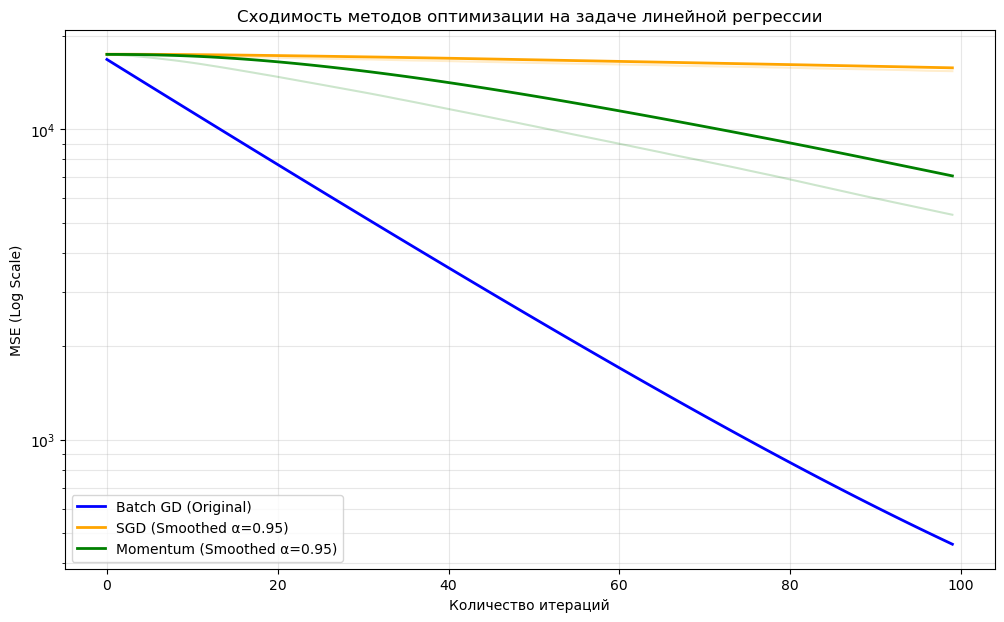

In [108]:
import matplotlib.pyplot as plt


def smoothing(history, alpha=0.95):
    smoothed = []
    current_val = history[0]
    for loss in history:
        current_val = alpha * current_val + (1 - alpha) * loss 
        smoothed.append(current_val)
    return smoothed
        



w_bgd, hist_bgd = batch_gd(X, y, lr=0.01, n_iter=100)
w_sgd, hist_sgd = sgd(X, y, lr=0.01, n_iter=100) 
w_mom, hist_mom = sgd_momentum(X, y, lr=0.01, n_iter=100)

hist_sgd_smooth = smoothing(hist_sgd, alpha=0.95)
hist_mom_smooth = smoothing(hist_mom, alpha=0.95)



plt.figure(figsize=(12, 7))

plt.plot(hist_bgd, label='Batch GD (Original)', color='blue', linewidth=2)

plt.plot(hist_sgd, color='orange', alpha=0.2) 
plt.plot(hist_sgd_smooth, label='SGD (Smoothed α=0.95)', color='orange', linewidth=2)


plt.plot(hist_mom, color='green', alpha=0.2) # Фон
plt.plot(hist_mom_smooth, label='Momentum (Smoothed α=0.95)', color='green', linewidth=2)

plt.yscale('log')
plt.xlabel('Количество итераций')
plt.ylabel('MSE (Log Scale)')
plt.title('Сходимость методов оптимизации на задаче линейной регрессии')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

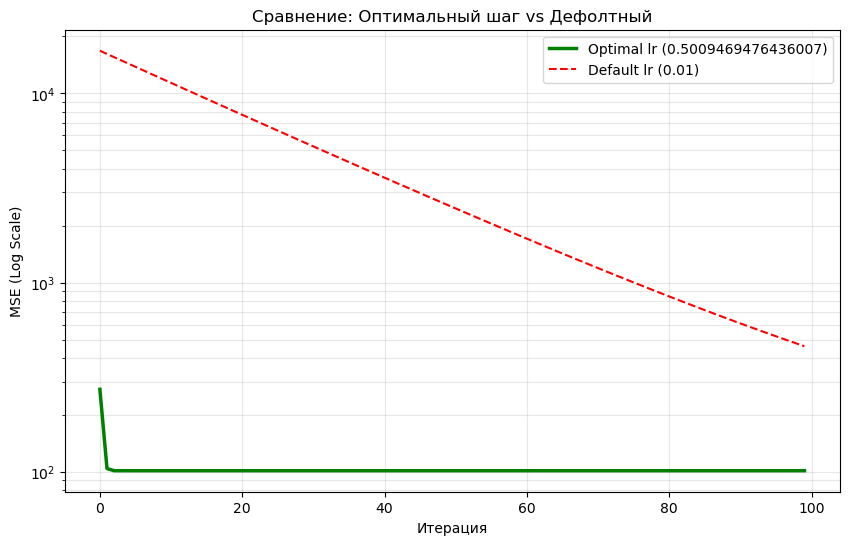

Финальный MSE (Оптимальный): 101.3591
Финальный MSE (Дефолтный): 461.0691


In [128]:


import matplotlib.pyplot as plt
import numpy as np


eta_op = 0.5009469476436007

w_opt, hist_opt = batch_gd(X, y, lr=eta_opt, n_iter=100)


w_def, hist_def = batch_gd(X, y, lr=0.01, n_iter=100)


plt.figure(figsize=(10, 6))

plt.plot(hist_opt, label=f'Optimal lr ({eta_opt})', color='green', linewidth=2.5)
plt.plot(hist_def, label='Default lr (0.01)', color='red', linestyle='--')

plt.yscale('log') 
plt.xlabel('Итерация')
plt.ylabel('MSE (Log Scale)')
plt.title('Сравнение: Оптимальный шаг vs Дефолтный')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()


print(f"Финальный MSE (Оптимальный): {hist_opt[-1]:.4f}")
print(f"Финальный MSE (Дефолтный): {hist_def[-1]:.4f}")

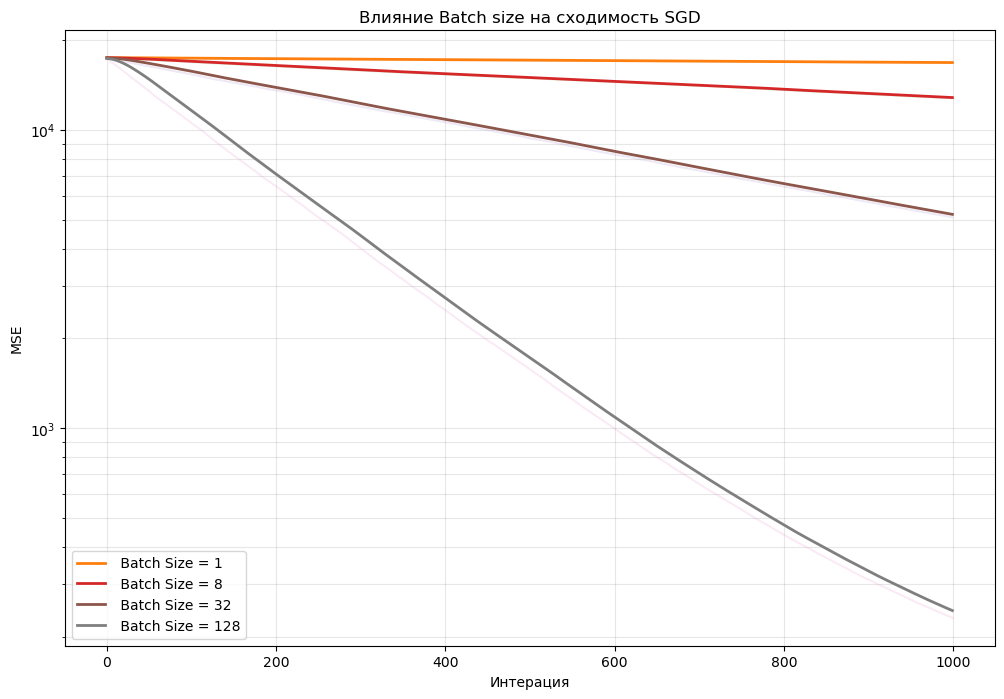

In [134]:



batch_sizes = [1,8,32,128]
relust = {}

plt.figure(figsize = (12,8))

for bs in batch_sizes: 
    w_bs, hist_bs = sgd(X, y , lr= 0.01, batch_size = bs , n_iter = 1000)
    hist_smooth = smoothing(hist_bs, alpha = 0.95)

    plt.plot(hist_bs ,alpha = 0.15)
    plt.plot(hist_smooth, label = f' Batch Size = {bs}', linewidth = 2 )

plt.yscale('log')
plt.xlabel('Интерация')
plt.ylabel('MSE')
plt.title('Влияние Batch size на сходимость SGD')
plt.legend()
plt.grid(True, which= 'both' , alpha = 0.3)
plt.show()
    

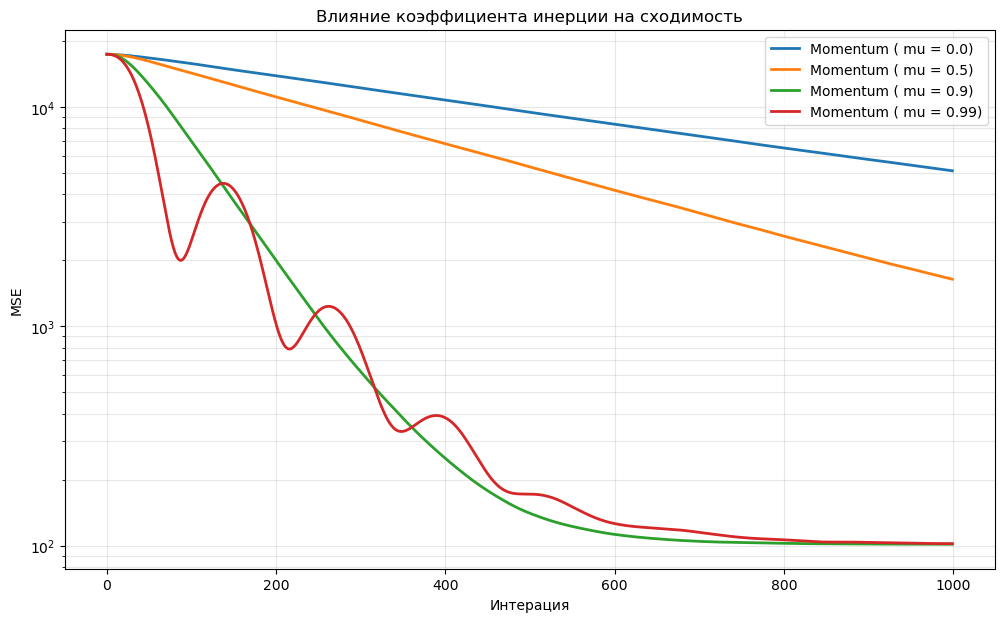

In [140]:


mus = [0.0, 0.5, 0.9 , 0.99]
plt.figure(figsize= (12,7))

for m in mus:
    w_m, hist_m  = sgd_momentum(X, y , lr = 0.01, momentum = m , batch_size = 32 , n_iter = 1000)
    hist_smooth = smoothing(hist_m , alpha = 0.95)
    plt.plot(hist_smooth, label = f'Momentum ( mu = {m})', linewidth = 2)

plt.yscale('log')
plt.xlabel('Интерация')
plt.ylabel('MSE')
plt.title('Влияние коэффициента инерции на сходимость' )
plt.legend()
plt.grid(True, which = 'both' , alpha = 0.3)
plt.show()

In [153]:
def get_metrics(history, thresholds=[100.0, 15.0]):
    results = {}
    for t in thresholds:
        iteration = next((i for i, loss in enumerate(history) if loss < t), "Не достигнуто")
        results[t] = iteration
    return results


res_bgd = get_metrics(hist_bgd)
res_sgd = get_metrics(hist_sgd)
res_mom = get_metrics(hist_mom)

print(f"Batch GD: MSE < 100 на {res_bgd[100.0]}, MSE < 15 на {res_bgd[15.0]}")
print(f"SGD:      MSE < 100 на {res_sgd[100.0]}, MSE < 15 на {res_sgd[15.0]}")
print(f"Momentum: MSE < 100 на {res_mom[100.0]}, MSE < 15 на {res_mom[15.0]}")

Batch GD: MSE < 100 на Не достигнуто, MSE < 15 на Не достигнуто
SGD:      MSE < 100 на Не достигнуто, MSE < 15 на Не достигнуто
Momentum: MSE < 100 на Не достигнуто, MSE < 15 на Не достигнуто
